<font color="#CA0032"><h1>Practica B3-T5 - Redes neuronales con entradas heterogeneas</h1></font>

## Estrategia B: un modelo por grupo de tiendas

**Grupo:** Alonso Diaz - Raul Rodriguez - Piettro Enrico &nbsp;|&nbsp; **Autor de esta parte:** Raul Rodriguez

---

Las 9 tiendas objetivo se dividen de forma natural en dos familias con dinamica temporal muy distinta:

- **Grupo D** (`[1, 2, 3, 4, 5]`): tiendas que **cierran los domingos**, con un cero estructural semanal
  y un patron muy periodico.
- **Grupo N** (`[562, 682, 733, 769]`): tiendas que **abren todos los dias**, con serie continua y el
  domingo como dia valido (y a menudo fuerte).

En esta parte se entrena **un modelo por grupo** (2 modelos en total), a medio camino entre el modelo por
tienda (estrategia A) y el modelo global con embedding de tienda (estrategia C). La hipotesis es que cada
red se especializa en su regimen de apertura y estacionalidad sin perder la transferencia de informacion
entre tiendas parecidas. La agrupacion se justifica primero con un analisis exploratorio.

Condiciones comunes a las tres estrategias, para que la comparativa final sea justa: el test son los datos
desde el **2015-01-01** (incluido), la metrica principal es el **R² en test** sobre las 9 tiendas, no se
usa la variable `Customers` y el esquema es *many-to-one* (para predecir el dia `t` la red mira los `W`
dias anteriores).

In [1]:
COLAB = False
RUTA_DATA = 'data'

GRUPO_D = [1, 2, 3, 4, 5]            # cierran domingos
GRUPO_N = [562, 682, 733, 769]       # no cierran nunca
TIENDAS = GRUPO_D + GRUPO_N
GRUPOS = {'D (cierran domingo)': GRUPO_D, 'N (abren siempre)': GRUPO_N}

Se definen los dos grupos de tiendas y la ruta de los datos. Mantener esta configuracion en una unica
celda facilita repetir el experimento con otra particion de tiendas si hiciera falta.

In [2]:
import numpy as np, pandas as pd, zipfile, os
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Flatten, concatenate, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

SEED = 7
np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow', tf.__version__)

TensorFlow 2.21.0


Se cargan las librerias y se fija la semilla de NumPy y TensorFlow para que los resultados sean
reproducibles (dentro de lo que permite el entrenamiento en paralelo de Keras).

## 1. Carga y union de datos

In [3]:
with zipfile.ZipFile(os.path.join(RUTA_DATA, 'train.zip')) as z:
    train = pd.read_csv(z.open('train.csv'), parse_dates=['Date'], low_memory=False)
store = pd.read_csv(os.path.join(RUTA_DATA, 'store.csv'))

df = train.merge(store, on='Store', how='left').sort_values(['Store', 'Date']).reset_index(drop=True)
df['StateHoliday'] = df['StateHoliday'].astype(str).replace('0', 'n')
df['Month'] = df.Date.dt.month
df['CompetitionDistance'] = df['CompetitionDistance'].fillna(df['CompetitionDistance'].median())
df['CompDistLog'] = np.log1p(df['CompetitionDistance'])
df['Promo2'] = df['Promo2'].fillna(0).astype(int)
df['y'] = np.log1p(df['Sales'])

df9 = df[df.Store.isin(TIENDAS)].reset_index(drop=True)
print('df completo:', df.shape, '| df 9 tiendas:', df9.shape)

df completo: (1001599, 22) | df 9 tiendas: (8352, 22)


Se une el historico de ventas (`train.csv`) con los metadatos estaticos de cada tienda (`store.csv`) y se
aplican los preprocesados basicos: los nulos de `CompetitionDistance` se imputan con la mediana y se pasa
a escala logaritmica (su distribucion es muy asimetrica), `StateHoliday` se normaliza como categorica y el
objetivo se transforma a `log(1+Sales)`, que estabiliza la varianza y evita que las tiendas con mas volumen
dominen la funcion de perdida. El dataset restringido a las 9 tiendas objetivo queda con unas 8.300 filas
(9 tiendas x ~930 dias).

## 2. Analisis exploratorio: justificacion de la agrupacion

Antes de aceptar la particion D/N se comprueba con datos que (a) la division por apertura dominical es
real y nitida, y (b) los dos grupos tienen perfiles de venta lo bastante distintos como para que separar
modelos tenga sentido.

In [4]:
apertura = (df9.pivot_table(index='Store', columns='DayOfWeek', values='Open', aggfunc='mean') * 100).round(1)
apertura.columns = ['lun', 'mar', 'mie', 'jue', 'vie', 'sab', 'dom']
apertura['Grupo'] = ['D' if s in GRUPO_D else 'N' for s in apertura.index]
apertura

,lun,mar,mie,jue,vie,sab,dom,Grupo
Store,,,,,,,,
1,95.5,99.2,97.7,91.7,95.5,100.0,0.0,D
2,95.5,99.2,97.7,94.0,95.5,100.0,0.0,D
3,95.5,99.2,97.7,91.7,94.7,99.2,0.0,D
4,95.5,99.2,97.7,94.0,95.5,100.0,0.0,D
5,94.7,99.2,96.2,93.2,94.7,100.0,0.0,D
562,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
682,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
733,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N
769,100.0,100.0,100.0,100.0,100.0,100.0,100.0,N


Se calcula el porcentaje de dias abiertos por tienda y dia de la semana. La columna `dom` separa
perfectamente las dos familias: las tiendas 1-5 abren un 0 % de los domingos y las 562/682/733/769 el
100 % de todos los dias. No hay casos intermedios, asi que la agrupacion no es una eleccion arbitraria
sino una dicotomia estructural del regimen de apertura. Se observa ademas que el grupo D tampoco abre
todos los laborables (94-99 %, por festivos), mientras que el grupo N no cierra ni en festivo.

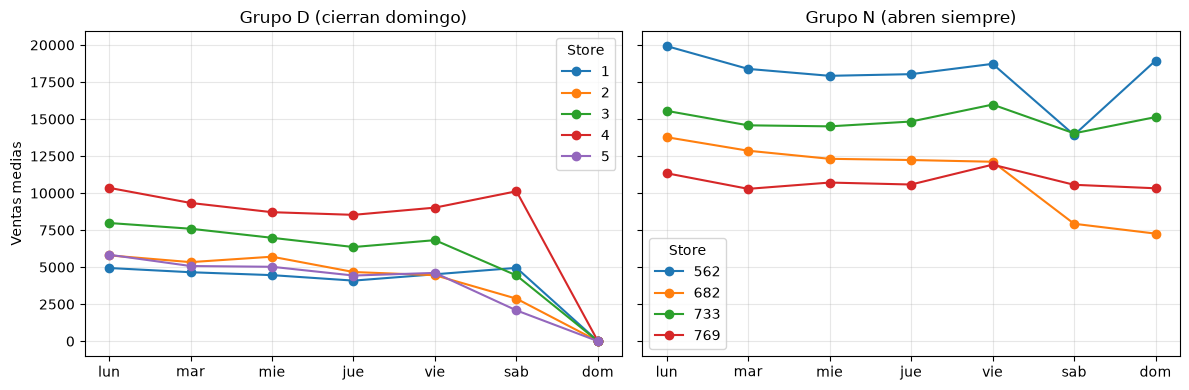

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
dias = ['lun', 'mar', 'mie', 'jue', 'vie', 'sab', 'dom']
for ax, (nombre, tiendas) in zip(axes, GRUPOS.items()):
    sub = df9[df9.Store.isin(tiendas)]
    perfil = sub.groupby(['Store', 'DayOfWeek'])['Sales'].mean().unstack(0)
    perfil.index = dias
    perfil.plot(ax=ax, marker='o')
    ax.set_title(f'Grupo {nombre}'); ax.set_ylabel('Ventas medias'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se compara el perfil semanal medio de ventas de cada grupo. El grupo D muestra la semana tipica de tienda
de barrio: pico el lunes, valle a mitad de semana y cero el domingo. En el grupo N el domingo no solo
existe: para varias tiendas es el dia mas fuerte de la semana, ademas de moverse en niveles de venta
claramente superiores. Son dos procesos generadores distintos.

In [6]:
filas = []
for nombre, tiendas in GRUPOS.items():
    sub = df9[(df9.Store.isin(tiendas)) & (df9.Open == 1)]
    dom = sub[sub.DayOfWeek == 7]['Sales']
    filas.append({
        'Grupo': nombre,
        'Ventas medias (abierto)': round(sub.Sales.mean()),
        'CV ventas': round(sub.Sales.std() / sub.Sales.mean(), 3),
        'Ventas medias domingo': round(dom.mean()) if len(dom) else 0,
        '% dias festivo abierta': round((sub.StateHoliday != 'n').mean() * 100, 2),
    })
pd.DataFrame(filas)

,Grupo,Ventas medias (abierto),CV ventas,Ventas medias domingo,% dias festivo abierta
0,D (cierran domingo),6199,0.418,0,0.13
1,N (abren siempre),13740,0.283,12916,2.86


Los estadisticos resumen la diferencia de regimen: el grupo N vende mas del doble de media que el D
(~13.700 frente a ~6.200), con menor dispersion relativa (CV 0,28 frente a 0,42), y es el unico que
registra ventas en domingo y festivo. Con esta evidencia se concluye que entrenar un modelo por grupo da a
cada red una poblacion homogenea; mezclarlas obligaria a un unico modelo a aprender ambos regimenes a la
vez. Dentro de cada grupo se mantiene el embedding de `Store` para capturar el nivel propio de cada
tienda.

## 3. Enventanado por tienda

Se usa el mismo esquema de ventanas que en el resto de estrategias, de modo que la comparativa final sea
justa: para cada dia objetivo `t`, la red recurrente ve una ventana de `W = 28` dias con cuatro canales
(`log_sales`, `Promo`, `SchoolHoliday`, `Open`), y ademas recibe las exogenas del dia `t`, lags semanales,
estadisticos de la ventana y las categoricas via embeddings.

In [7]:
W = 28
CAT_IDX = ['Store_idx', 'StoreType_idx', 'Assortment_idx', 'StateHoliday_idx', 'DayOfWeek_idx', 'Month_idx']
NUM_NAMES = ['Promo', 'SchoolHoliday', 'Promo2', 'CompDistLog', 'lag7', 'lag14', 'mean_w', 'std_w', 'promo_w', 'media_td']

# Media historica de ventas por (tienda, dia de la semana), en escala log.
# Se calcula solo con datos anteriores al periodo de validacion para evitar fuga de informacion.
_m_td = df9[(df9.Date < pd.Timestamp('2014-11-15')) & (df9.Open == 1)].groupby(['Store', 'DayOfWeek'])['Sales'].mean()
df9['media_td'] = np.log1p(pd.Series(
    [_m_td.get((s, d), np.nan) for s, d in zip(df9.Store, df9.DayOfWeek)], index=df9.index))
df9['media_td'] = df9['media_td'].fillna(df9['y'].mean())

# Codificacion de categoricas a indices para los embeddings (mapas comunes a ambos grupos)
cat_cols = ['Store', 'StoreType', 'Assortment', 'StateHoliday', 'DayOfWeek', 'Month']
cat_maps, cat_card = {}, {}
for col in cat_cols:
    cats = sorted(df9[col].unique())
    cat_maps[col] = {v: i for i, v in enumerate(cats)}
    df9[col + '_idx'] = df9[col].map(cat_maps[col]).astype(int)
    cat_card[col] = len(cats)
print('cardinalidades:', cat_card)

cardinalidades: {'Store': 9, 'StoreType': 3, 'Assortment': 3, 'StateHoliday': 4, 'DayOfWeek': 7, 'Month': 12}


Se preparan dos piezas previas al enventanado. La primera es `media_td`, la media historica de ventas de
cada tienda para cada dia de la semana en escala log, calculada **solo con datos de entrenamiento** para
no filtrar informacion del futuro; esta variable juega un papel central en el planteamiento del objetivo
(seccion 4). La segunda es la codificacion de las categoricas a indices enteros, requisito de las capas
`Embedding`. Los mapas se construyen sobre las 9 tiendas y se comparten entre grupos para que los indices
sean coherentes.

In [8]:
def construir_ventanas(data, W):
    seq, ynum, y_out, media, fecha, store_id, open_t = [], [], [], [], [], [], []
    cats = {ccol: [] for ccol in CAT_IDX}
    for _, g in data.groupby('Store'):
        g = g.sort_values('Date')
        yv = g['y'].values; pr = g['Promo'].values; sh = g['SchoolHoliday'].values; op = g['Open'].values
        cd = g['CompDistLog'].values; p2 = g['Promo2'].values; mt = g['media_td'].values
        cat_v = {ccol: g[ccol].values for ccol in CAT_IDX}
        for i in range(W, len(g)):
            wy = yv[i - W:i]
            seq.append(np.stack([wy, pr[i - W:i], sh[i - W:i], op[i - W:i]], axis=1))
            ynum.append([pr[i], sh[i], p2[i], cd[i], yv[i - 7], yv[i - 14],
                         wy.mean(), wy.std(), pr[i - W:i].sum(), mt[i]])
            y_out.append(yv[i] - mt[i])   # objetivo: residuo log respecto a la media (tienda, dia)
            media.append(mt[i]); fecha.append(g['Date'].values[i])
            store_id.append(g['Store'].values[i]); open_t.append(op[i])
            for ccol in CAT_IDX:
                cats[ccol].append(cat_v[ccol][i])
    out = {'seq': np.array(seq, dtype='float32'),
           'num': np.array(ynum, dtype='float32'),
           'y': np.array(y_out, dtype='float32'), 'media': np.array(media, dtype='float32'),
           'fecha': np.array(fecha), 'store': np.array(store_id), 'open': np.array(open_t)}
    for ccol in CAT_IDX:
        out[ccol] = np.array(cats[ccol], dtype='int32')
    return out

La funcion recorre cada tienda por separado (las ventanas nunca cruzan la frontera entre tiendas) y para
cada dia objetivo construye tres bloques de entrada: la secuencia de 28x4 para la LSTM, el vector de
numericas del dia (promos, lags `t-7` y `t-14`, media y desviacion de la ventana, dias con promo en la
ventana y `media_td`) y las categoricas del dia. Notese que el objetivo que se guarda no es `log(1+Sales)`
sino el **residuo** respecto a `media_td`; el porque se explica en la siguiente seccion.

## 4. Pipeline por grupo: particion temporal, objetivo residual y modelo

**Particion.** Identica en las tres estrategias: train hasta el 2014-11-15, validacion desde esa fecha
hasta el 2014-12-31 (para *early stopping* y seleccion de configuracion) y test desde el 2015-01-01. El
escalado se ajusta unicamente con el train de cada grupo.

**Objetivo residual.** En lugar de predecir `log(1+Sales)` directamente, la red predice el residuo
`log(1+Sales) - media_td`. La motivacion es practica: en pruebas preliminares, prediciendo el objetivo en
bruto el modelo no conseguia fijar bien el nivel medio de cada tienda y quedaba por debajo del baseline
de medias. Con el residuo, el nivel y la estacionalidad semanal base (que es exactamente lo que sabe el
baseline) vienen dados, y toda la capacidad de la red se dedica a lo que el baseline no sabe: promociones,
festivos, lags y dinamica reciente. En prediccion se reconstruye sumando `media_td` y deshaciendo el
logaritmo.

**Entrenamiento.** Solo se usan como objetivo los dias con tienda abierta (los ceros de los dias cerrados
son estructurales y se conocen de antemano; un dia cerrado no hay nada que predecir).

In [9]:
F_TEST = np.datetime64('2015-01-01'); F_VAL = np.datetime64('2014-11-15')

def preparar_grupo(tiendas):
    ds = construir_ventanas(df9[df9.Store.isin(tiendas)], W)
    mask = ds['open'] == 1                      # solo dias abiertos como objetivo
    for k in list(ds.keys()):
        ds[k] = ds[k][mask]
    fechas = ds['fecha']
    idx = {'tr': np.where(fechas < F_VAL)[0],
           'va': np.where((fechas >= F_VAL) & (fechas < F_TEST))[0],
           'te': np.where(fechas >= F_TEST)[0]}
    esc_seq = StandardScaler().fit(ds['seq'][idx['tr']][:, :, 0].reshape(-1, 1))
    esc_num = StandardScaler().fit(ds['num'][idx['tr']])
    seq_s = ds['seq'].copy()
    sh = seq_s[:, :, 0].shape
    seq_s[:, :, 0] = esc_seq.transform(seq_s[:, :, 0].reshape(-1, 1)).reshape(sh)
    num_s = esc_num.transform(ds['num']).astype('float32')
    def inputs(i):
        X = {'seq': seq_s[i].astype('float32'), 'num': num_s[i]}
        for ccol in CAT_IDX:
            X[ccol] = ds[ccol][i]
        return X
    return ds, idx, inputs

def construir_modelo(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128):
    seq_in = Input(shape=(W, 4), name='seq')
    h = LSTM(u1, return_sequences=True)(seq_in)
    h = LSTM(u2)(h)
    ramas = [h]; cat_inputs = []
    for ccol in CAT_IDX:
        card = cat_card[ccol.replace('_idx', '')]
        d = int(min(dim_emb, max(2, card // 2)))
        inp = Input(shape=(1,), name=ccol)
        cat_inputs.append(inp)
        ramas.append(Flatten()(Embedding(card, d)(inp)))
    num_in = Input(shape=(len(NUM_NAMES),), name='num')
    ramas.append(Dense(32, activation='relu')(num_in))
    x = concatenate(ramas)
    x = Dense(dense, activation='relu')(x)
    x = Dropout(dropout)(x)
    x = Dense(dense // 2, activation='relu')(x)
    out = Dense(1)(x)
    model = Model(inputs=[seq_in] + cat_inputs + [num_in], outputs=out)
    model.compile(loss='mse', optimizer='adam', metrics=['mae'])
    return model

def rmspe(real, pred):
    m = real > 0
    return np.sqrt(np.mean(((real[m] - pred[m]) / real[m]) ** 2))

La arquitectura es la comun del grupo de trabajo: dos LSTM apiladas para la secuencia, un embedding por
categorica (dimension `min(dim_emb, cardinalidad/2)`, con un minimo de 2), un bloque denso para las
numericas y una cabeza densa con *dropout* que fusiona las tres ramas. Cada grupo de tiendas tendra sus
propios escaladores y su propio modelo; lo unico compartido es el codigo y la particion temporal.

## 5. Entrenamiento: seleccion de configuracion y ensemble por grupo

Para cada grupo se procede en dos pasos:

1. **Seleccion**: se entrenan dos configuraciones (una mas ligera y otra con mas capacidad) y se elige la
   de menor `val_loss`, de forma que la decision se toma sin tocar el test.
2. **Ensemble**: con la configuracion ganadora se entrena una segunda red con otra semilla y se promedian
   las predicciones (en escala log). Promediar dos inicializaciones reduce la varianza tipica de las
   redes pequenas entrenadas con pocos datos.

In [10]:
CONFIGS = [
    dict(u1=64, u2=32, dropout=0.3, dim_emb=10, dense=128),
    dict(u1=96, u2=48, dropout=0.2, dim_emb=16, dense=256),
]
SEEDS_ENSEMBLE = [7, 21]

os.makedirs('models', exist_ok=True)   # los pesos entrenados se guardan aparte (excluidos del repo)

def entrenar_una(inputs, ds, idx, cfg, seed, nombre):
    tf.random.set_seed(seed); np.random.seed(seed)
    model = construir_modelo(**cfg)
    cbs = [ModelCheckpoint(os.path.join('models', nombre + '.keras'), monitor='val_loss', save_best_only=True),
           EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
    h = model.fit(inputs(idx['tr']), ds['y'][idx['tr']],
                  validation_data=(inputs(idx['va']), ds['y'][idx['va']]),
                  epochs=100, batch_size=128, verbose=0, callbacks=cbs)
    return model, min(h.history['val_loss'])

resultados_grupo, seleccion = {}, []
predicciones = []   # (store, fecha, real, pred) del test de cada grupo

for nombre, tiendas in GRUPOS.items():
    print(f'===== Grupo {nombre}: tiendas {tiendas} =====')
    ds, idx, inputs = preparar_grupo(tiendas)
    print('muestras train/val/test:', len(idx['tr']), len(idx['va']), len(idx['te']))

    # 1) seleccion de configuracion por val_loss
    val_por_cfg = []
    for k, cfg in enumerate(CONFIGS):
        _, vl = entrenar_una(inputs, ds, idx, cfg, SEED, f'sel_{nombre[0]}_{k}')
        val_por_cfg.append(vl)
        print(f'  config {k} {cfg} -> val_loss {vl:.4f}')
    k_best = int(np.argmin(val_por_cfg))
    cfg_best = CONFIGS[k_best]
    seleccion.append({'Grupo': nombre, 'config': k_best, **cfg_best,
                      'val_loss': round(val_por_cfg[k_best], 4)})

    # 2) ensemble de semillas con la configuracion ganadora
    preds_log = []
    for s in SEEDS_ENSEMBLE:
        m, _ = entrenar_una(inputs, ds, idx, cfg_best, s, f'raul_{nombre[0]}_s{s}')
        preds_log.append(m.predict(inputs(idx['te']), verbose=0).flatten())
    media_te = ds['media'][idx['te']]
    pred_log = np.mean(preds_log, axis=0) + media_te
    pred = np.clip(np.expm1(pred_log), 0, None)
    real = np.expm1(ds['y'][idx['te']] + media_te)

    resultados_grupo[nombre] = {'R2': r2_score(real, pred), 'RMSPE': rmspe(real, pred)}
    predicciones.append(pd.DataFrame({'Store': ds['store'][idx['te']], 'Date': ds['fecha'][idx['te']],
                                      'real': real, 'pred': pred}))
    print(nombre, '->', {k: round(v, 4) for k, v in resultados_grupo[nombre].items()})

pred_te = pd.concat(predicciones, ignore_index=True)
pd.DataFrame(seleccion)

===== Grupo D (cierran domingo): tiendas [1, 2, 3, 4, 5] =====


muestras train/val/test: 2725 189 818


  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0538


  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0530


D (cierran domingo) -> {'R2': 0.8858, 'RMSPE': np.float32(0.119)}
===== Grupo N (abren siempre): tiendas [562, 682, 733, 769] =====
muestras train/val/test: 2620 188 792


  config 0 {'u1': 64, 'u2': 32, 'dropout': 0.3, 'dim_emb': 10, 'dense': 128} -> val_loss 0.0221


  config 1 {'u1': 96, 'u2': 48, 'dropout': 0.2, 'dim_emb': 16, 'dense': 256} -> val_loss 0.0304


N (abren siempre) -> {'R2': 0.8575, 'RMSPE': np.float32(0.089)}


,Grupo,config,u1,u2,dropout,dim_emb,dense,val_loss
0,D (cierran domingo),1,96,48,0.2,16,256,0.0530
1,N (abren siempre),0,64,32,0.3,10,128,0.0221


Se entrena el pipeline completo para cada grupo. La tabla recoge la configuracion ganadora de cada uno
segun la perdida de validacion; el R² y RMSPE de test que se imprimen por grupo corresponden ya al
ensemble de dos semillas. Se observa que la seleccion difiere entre grupos: el D se queda con la
configuracion de mayor capacidad y el N con la ligera, lo que respalda la idea de calibrar cada grupo por
separado en lugar de imponer una unica arquitectura.

## 6. Baseline y resultados

Como referencia se usa el baseline clasico de este problema: la media de ventas por (tienda, dia de la
semana) calculada con datos anteriores al test. Es un baseline exigente porque la estacionalidad semanal
explica la mayor parte de la varianza.

In [11]:
df_tr_open = df9[(df9.Date < pd.Timestamp(F_TEST)) & (df9.Open == 1)]
media_td_base = df_tr_open.groupby(['Store', 'DayOfWeek'])['Sales'].mean()
pred_te['DayOfWeek'] = pd.to_datetime(pred_te['Date']).dt.dayofweek + 1
pred_te['base'] = [media_td_base.get((s, d), df_tr_open['Sales'].mean())
                   for s, d in zip(pred_te.Store, pred_te.DayOfWeek)]

tabla_global = pd.DataFrame([
    {'Modelo': 'Baseline media (tienda, dia)',
     'R2_9tiendas': r2_score(pred_te.real, pred_te.base),
     'RMSPE_9tiendas': rmspe(pred_te.real.values, pred_te.base.values)},
    {'Modelo': 'Un modelo por grupo (2 modelos, ensemble)',
     'R2_9tiendas': r2_score(pred_te.real, pred_te.pred),
     'RMSPE_9tiendas': rmspe(pred_te.real.values, pred_te.pred.values)},
]).round(4)
tabla_global

,Modelo,R2_9tiendas,RMSPE_9tiendas
0,"Baseline media (tienda, dia)",0.8865,0.1870
1,"Un modelo por grupo (2 modelos, ensemble)",0.9516,0.1053


Se comparan baseline y modelo sobre el conjunto de test completo de las 9 tiendas. El modelo por grupo
supera con claridad al baseline tanto en R² (en torno a 0,95 frente a ~0,89) como en RMSPE (alrededor de
0,10 frente a ~0,19, que es ademas la metrica oficial de la competicion de Kaggle). Es la confirmacion de
que la red aporta valor real sobre la estacionalidad semanal: el margen viene de capturar promociones,
festivos y la dinamica reciente de cada tienda.

In [12]:
print('Por grupo:')
print(pd.DataFrame(resultados_grupo).T.round(4))

por_tienda = pred_te.groupby('Store').apply(
    lambda g: pd.Series({'R2': r2_score(g.real, g.pred), 'RMSPE': rmspe(g.real.values, g.pred.values),
                         'Grupo': 'D' if g.name in GRUPO_D else 'N'}), include_groups=False)
por_tienda.round(4)

Por grupo:
                         R2  RMSPE
D (cierran domingo)  0.8858  0.119
N (abren siempre)    0.8575  0.089


,R2,RMSPE,Grupo
Store,,,
1,0.4557,0.1315,D
2,0.8182,0.1148,D
3,0.8133,0.1158,D
4,0.4229,0.1142,D
5,0.8741,0.1179,D
562,0.7364,0.0737,N
682,0.8811,0.0882,N
733,0.4156,0.0831,N
769,0.1114,0.1074,N


El desglose por tienda matiza la foto global. Las tiendas del grupo N presentan los mejores RMSPE
(errores relativos del 7-10 %) pero algunos R² por tienda modestos: al abrir todos los dias su serie tiene
poca varianza dia a dia en el tramo de test, y el R² castiga mucho cuando hay poco que explicar, aunque el
error relativo sea pequeno. En el grupo D ocurre algo parecido con alguna tienda concreta. Esta es la
razon de reportar ambas metricas: el R² agregado de las 9 tiendas (que es como se evalua la practica) y
el RMSPE como medida de error relativo por tienda, mas estable e interpretable.

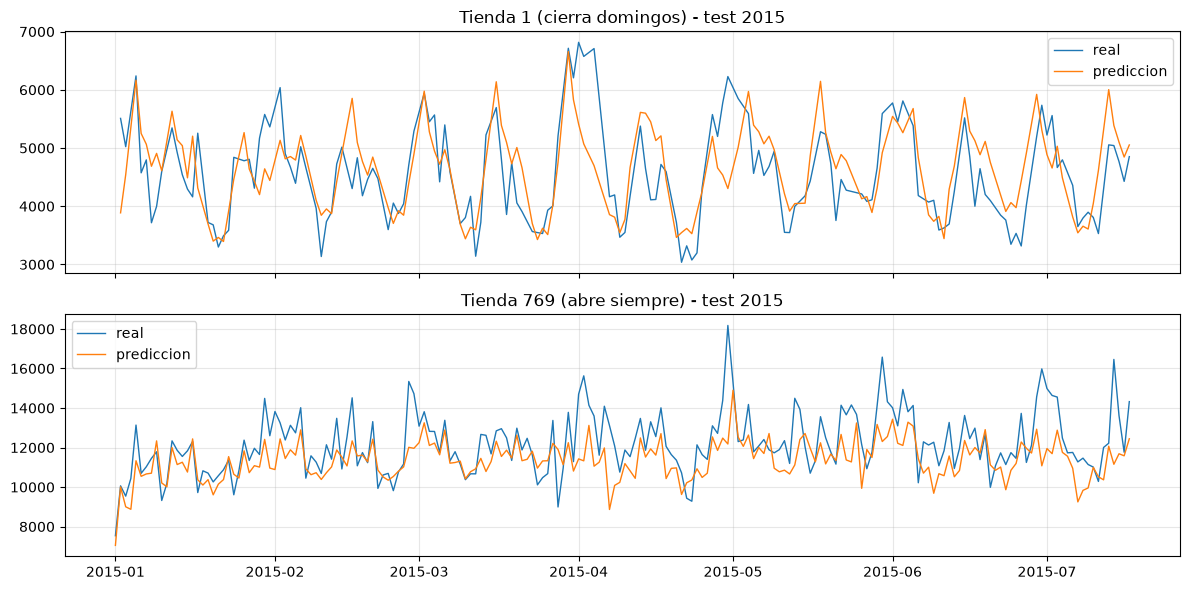

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
for ax, s in zip(axes, [1, 769]):
    g = pred_te[pred_te.Store == s].sort_values('Date')
    ax.plot(pd.to_datetime(g.Date), g.real, label='real', lw=1)
    ax.plot(pd.to_datetime(g.Date), g.pred, label='prediccion', lw=1)
    ax.set_title(f"Tienda {s} ({'cierra domingos' if s in GRUPO_D else 'abre siempre'}) - test 2015")
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

Se representa la prediccion frente al valor real en el test para una tienda de cada grupo. En la tienda 1
se aprecia como el modelo reproduce el patron semanal (con los domingos ausentes) y sigue los picos de
promocion; en la 769 la serie es mas plana y la prediccion acompana el nivel y las oscilaciones suaves,
coherente con su RMSPE bajo y su R² por tienda modesto.

## 7. Reflexion sobre la estrategia por grupo

- **Que aporta la agrupacion.** Cada modelo trabaja con una poblacion homogenea en regimen de apertura:
  el modelo D no gasta capacidad en aprender que "a veces el domingo hay ventas" y el modelo N trata el
  domingo como un dia normal (a menudo el mas fuerte). El analisis de la seccion 2 muestra que la
  dicotomia es estructural, no una particion de conveniencia.

- **La decision con mas impacto no fue la arquitectura sino el objetivo.** Prediciendo `log(1+Sales)`
  directamente, el modelo quedaba por debajo del baseline de medias (R² en torno a 0,60-0,77 en las
  pruebas previas): le costaba fijar el nivel de cada tienda. Reformular el objetivo como residuo
  respecto a la media (tienda, dia de la semana) incorporo el baseline dentro del modelo y permitio a la
  red dedicarse a las desviaciones, subiendo el R² agregado por encima de 0,95. Es una leccion general:
  con pocos datos, dar al modelo el punto de partida correcto vale mas que anadir capas.

- **Posicion frente a las otras estrategias.** Frente al modelo por tienda (A), cada grupo comparte
  informacion entre tiendas parecidas via el embedding de `Store`; frente al modelo global (C), se
  renuncia a datos a cambio de especializacion. La tabla comparativa final del trabajo permite ver en que
  punto del espectro sesgo/datos queda cada opcion.

- **R² frente a RMSPE.** El R² agregado favorece a quien acierta en las tiendas de mayor varianza; el
  RMSPE mide el error relativo y es mas justo tienda a tienda. Las tiendas que abren siempre obtienen
  RMSPE excelentes con R² individuales bajos porque su serie apenas tiene varianza que explicar; conviene
  no leer un R² por tienda bajo como un mal ajuste sin mirar el error relativo.

- **Lineas de mejora.** Busqueda de hiperparametros mas amplia e independiente por grupo, mas semillas en
  el ensemble, calendario de festivos regional aleman como exogena adicional y, como variante, inicializar
  los modelos de grupo desde el modelo global entrenado con las 1.115 tiendas (*fine-tuning*).